In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

---

### 26. Carregamento e inspeção inicial Carregue o dataset no Pandas. Liste tipos de dados e estatísticas descritivas (.info() e .describe()).

In [18]:
df_energy_data = pd.read_csv('./data/energydata_complete.csv')

df_energy_data['date'] = pd.to_datetime(df_energy_data['date'])

df_energy_data.info()
df_energy_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,2016-03-20 05:30:00,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
min,2016-01-11 17:00:00,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,2016-02-14 23:15:00,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,2016-03-20 05:30:00,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,2016-04-23 11:45:00,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,2016-05-27 18:00:00,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530
std,NaN,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634


---

### 27. Distribuição do consumo

- Crie histogramas e séries temporais para a variável Appliances.
- Pergunta: o consumo tende a se concentrar em valores baixos ou altos?


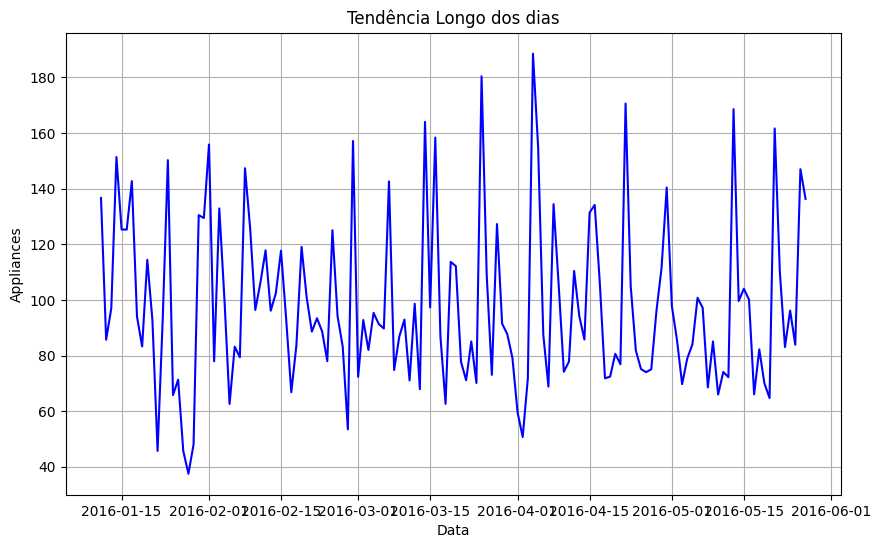

In [17]:
df_energy_data_group_by_date= df_energy_data.copy()
df_energy_data_group_by_date['simple_date'] = df_energy_data_group_by_date['date'].apply(lambda x: pd.to_datetime(str(x)[:10]))

df_energy_data_group_by_date = (
    df_energy_data_group_by_date.groupby(["simple_date"])
    .agg({"Appliances": "mean"})
    .reset_index()
)

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_data_group_by_date["simple_date"],
    df_energy_data_group_by_date["Appliances"],
    # marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Data")
plt.ylabel("Appliances")
plt.title("Tendência Longo dos dias")
plt.grid(True)
plt.show()


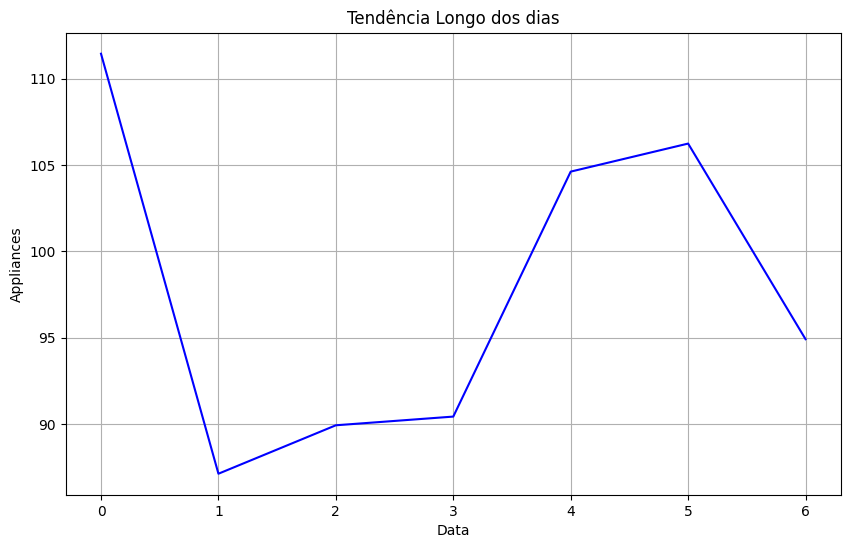

In [21]:
df_energy_data_group_by_day = df_energy_data.copy()

df_energy_data_group_by_day['week_day'] = df_energy_data_group_by_day['date'].apply(lambda x: datetime.date.weekday(x))

df_energy_data_group_by_day = (
    df_energy_data_group_by_day.groupby(["week_day"])
    .agg({"Appliances": "mean"})
    .reset_index()
)

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_data_group_by_day["week_day"],
    df_energy_data_group_by_day["Appliances"],
    # marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Data")
plt.ylabel("Appliances")
plt.title("Tendência Longo dos dias")
plt.grid(True)
plt.show()


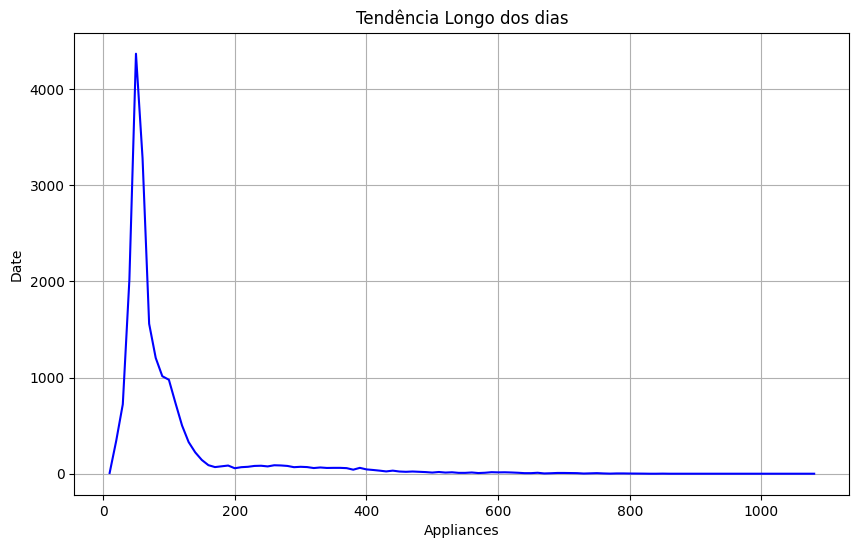

In [23]:
df_energy_data_group_by_applinances= df_energy_data.copy()

df_energy_data_group_by_applinances = (
    df_energy_data_group_by_applinances.groupby(["Appliances"])
    .agg({"date": "count"})
    .reset_index()
)

# Plotar a tendência de consumo ao longo dos anos
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_data_group_by_applinances["Appliances"],
    df_energy_data_group_by_applinances["date"],
    # marker="o",
    linestyle="-",
    color="b",
)
plt.xlabel("Appliances")
plt.ylabel("Date")
plt.title("Tendência Longo dos dias")
plt.grid(True)
plt.show()

- Foi possível observar que a variável appliances tem um padrão semanal.
- O consumo tende a se concentrar em valores baixos
- Ao realizar o processo de tratamento de outliers, provável que os valores acima de 200 serão removidos do dataset

---

### 28. Correlações com variáveis ambientais

- Calcule correlações entre Appliances e variáveis como temperatura e umidade.
- Pergunta: quais fatores têm mais relação com o consumo?


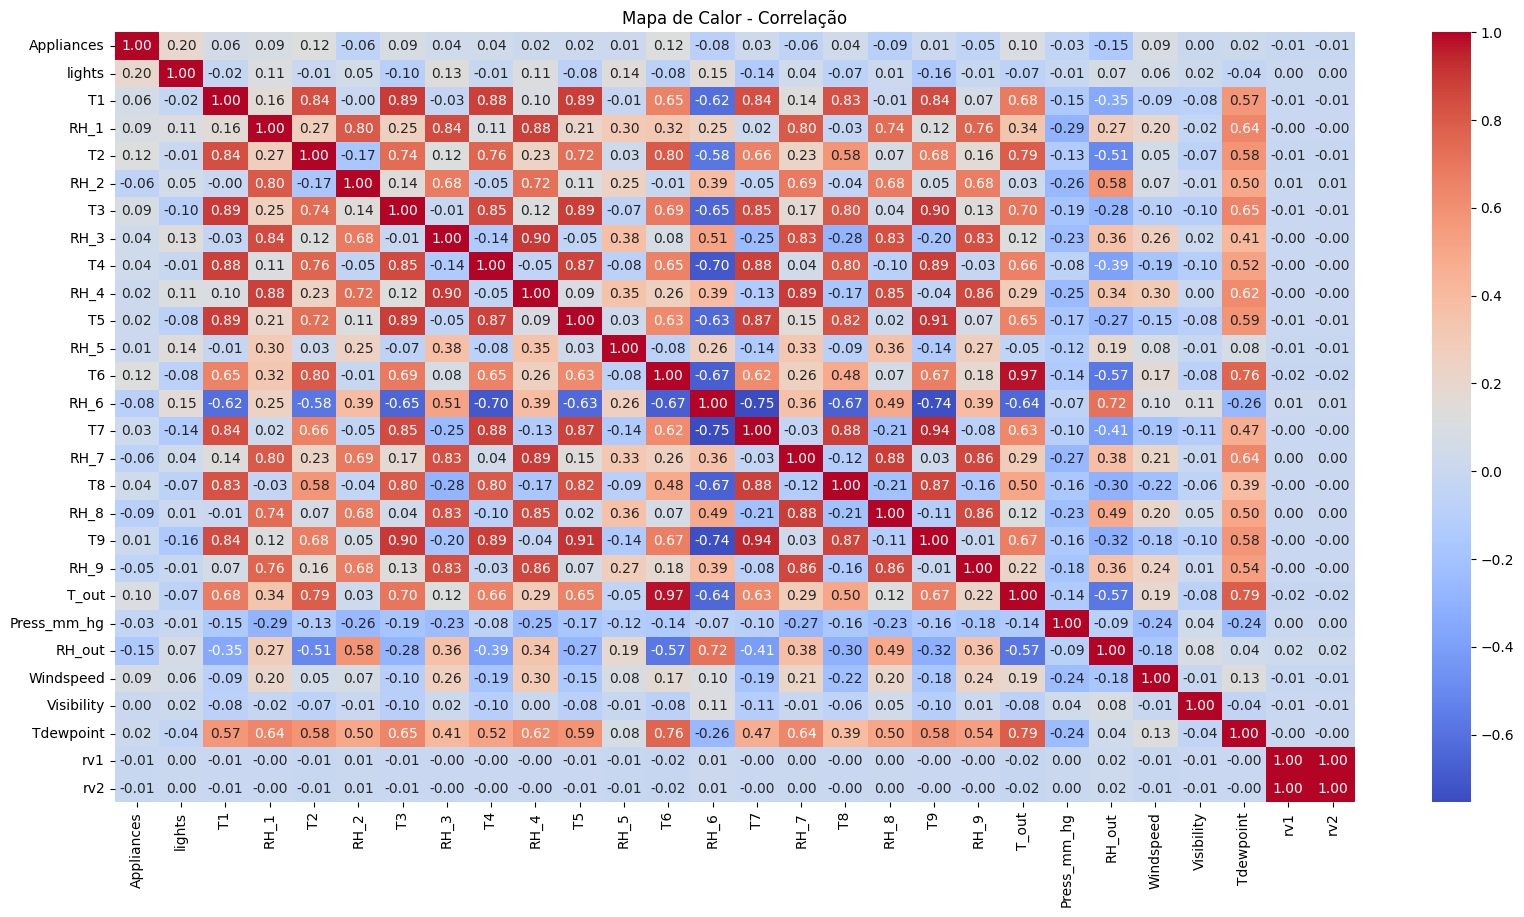

In [34]:
df_correlation = df_energy_data.select_dtypes(include=["number"])

# Calcula a matriz de correlação
corr = df_correlation.corr()

# Cria o mapa de calor
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Mapa de Calor - Correlação")
plt.show()

- **Nenhuma** variável tem correlação com o uso de energia
- Os fatores que possuem mais relação são Temperatura e humildade

---

### 29. Normalização dos dados

- Aplique Min-Max Scaling às variáveis numéricas.
- Reutilize esses dados em modelos posteriores.


In [35]:
df_numeric = df_energy_data.select_dtypes(include=["number"])

# Criando o scaler
scaler = MinMaxScaler()

# Aplicando transformação
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns
)

df_scaled.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,0.046729,0.428571,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,0.764262,...,0.223032,0.677290,0.372990,0.097674,0.894737,0.500000,0.953846,0.538462,0.265449,0.265449
1,0.046729,0.428571,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,0.782437,...,0.226500,0.678532,0.369239,0.100000,0.894737,0.476190,0.894872,0.533937,0.372083,0.372083
2,0.037383,0.428571,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,0.778062,...,0.219563,0.676049,0.365488,0.102326,0.894737,0.452381,0.835897,0.529412,0.572848,0.572848
3,0.037383,0.571429,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,0.770949,...,0.219563,0.671909,0.361736,0.104651,0.894737,0.428571,0.776923,0.524887,0.908261,0.908261
4,0.046729,0.571429,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,0.762697,...,0.219563,0.671909,0.357985,0.106977,0.894737,0.404762,0.717949,0.520362,0.201611,0.201611



---

### 30. PCA

- Aplique PCA e reduza para 2 componentes principais.
- Plote os dados resultantes.
- Pergunta: aparecem padrões ou agrupamentos naturais?
